# News/articles classificator

The purpose of this project is to create a classificator for news/articles using distilBERT language model.

## Data for model:
https://www.kaggle.com/datasets/timilsinabimal/newsarticlecategories

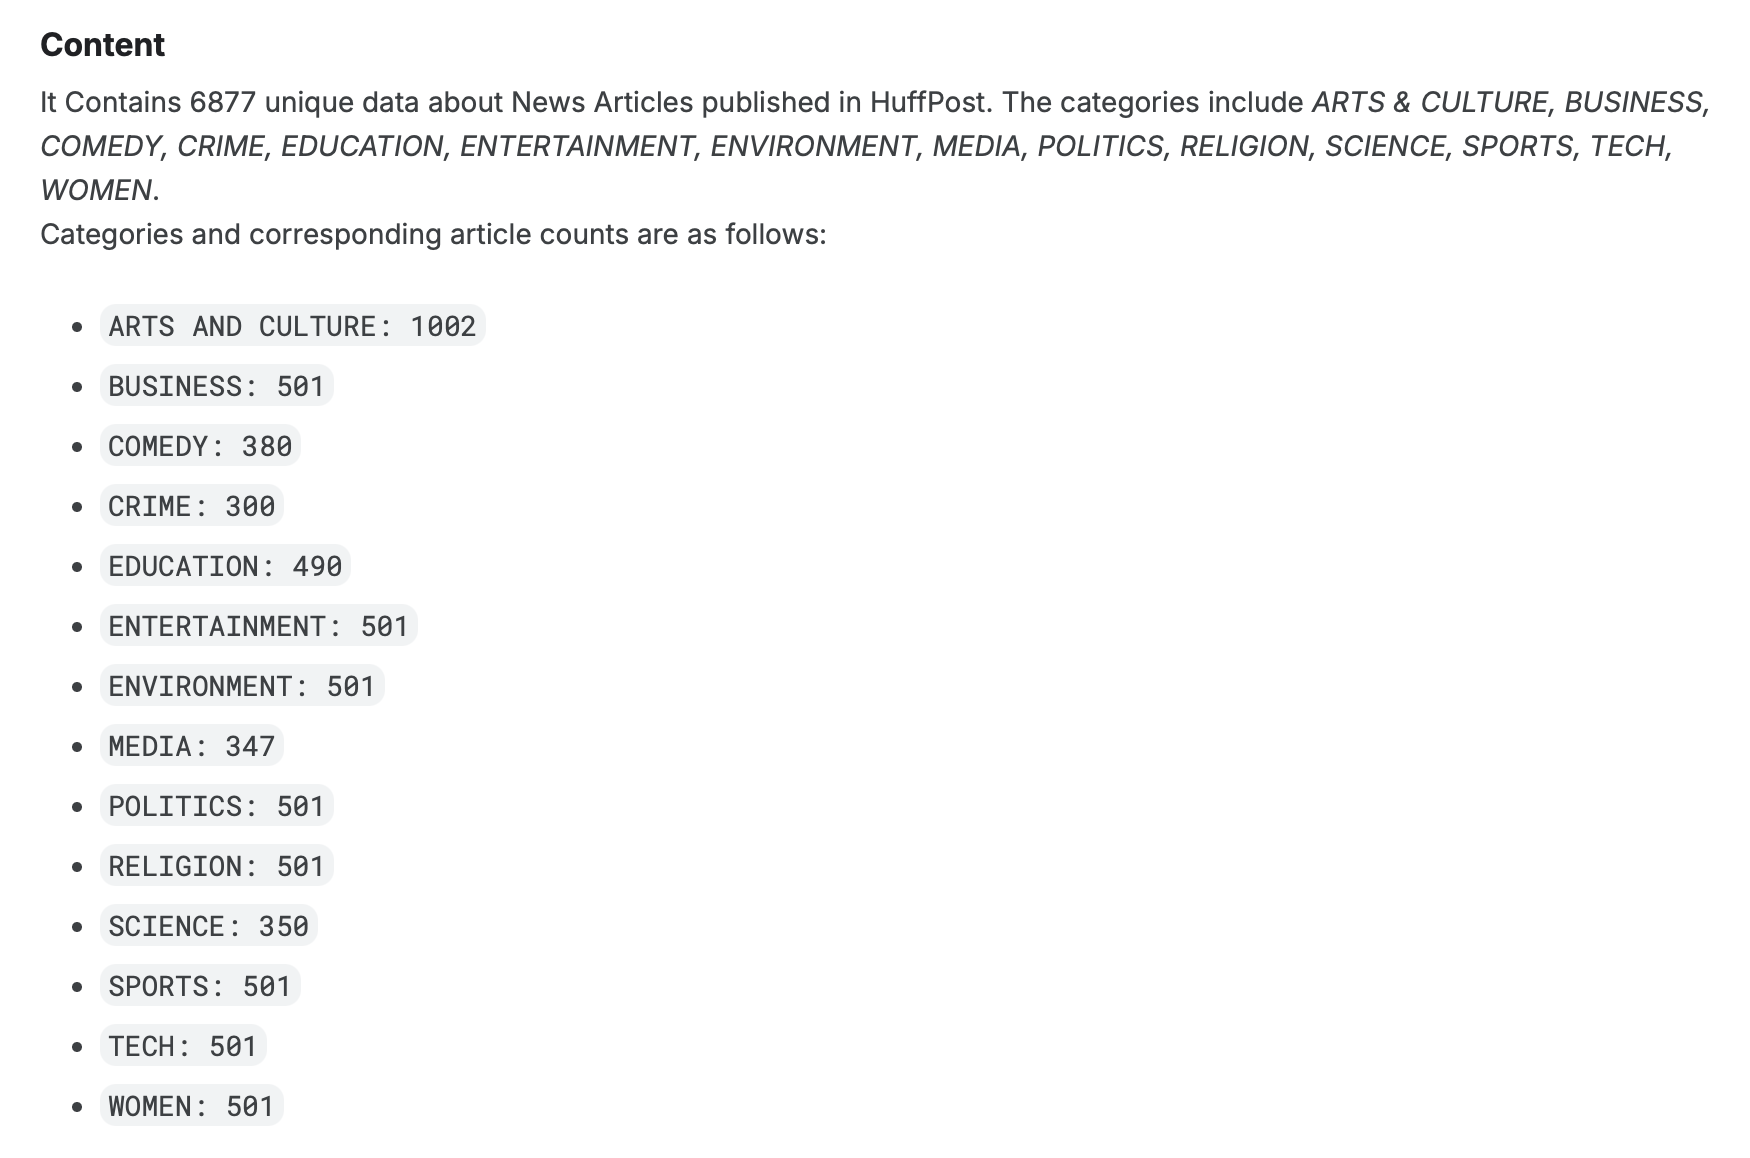

## Necessary imports

In [14]:
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

## Data loading and preparation

In [4]:
df = pd.read_csv('news-article-categories.csv')
df['text'] = df['title'].fillna('') + ' ' + df['body'].fillna('')
le = LabelEncoder()
df['labels'] = le.fit_transform(df['category'].astype(str))
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
train_dataset = Dataset.from_pandas(train_df[['text', 'labels']])
test_dataset = Dataset.from_pandas(test_df[['text', 'labels']])

## Tokenization using distilbert-base-uncased

In [5]:
tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')
def tokenize_function(examples):
    return tokenizer(examples['text'], truncation=True, padding='max_length', max_length=256)

train_dataset = train_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)
train_dataset.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])
test_dataset.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])

Map: 100%|██████████| 1376/1376 [00:00<00:00, 4626.12 examples/s]


# Setting up model and trainer with arguments

In [6]:
model = AutoModelForSequenceClassification.from_pretrained(
    'distilbert-base-uncased', 
    num_labels=len(le.classes_)
)

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_steps=50,
    load_best_model_at_end=True
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
)

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 2283.26it/s, Materializing param=distilbert.transformer.layer.5.sa_layer_norm.weight]   
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


# Training and evaluation

In [7]:
trainer.train()
trainer.save_model('./old_model')
print(f"Categories: {le.classes_}")
results = trainer.evaluate()
print(results)
print(f"Accuracy: {results.get('eval_accuracy', 'N/A')}")

/Users/karol/Desktop/CoursesUwr/7sem/Modele_językowe/Project/venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss
1,0.709838,0.663019
2,0.585035,0.660317
3,0.233504,0.735002


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  5.38it/s]
/Users/karol/Desktop/CoursesUwr/7sem/Modele_językowe/Project/venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  5.75it/s]
/Users/karol/Desktop/CoursesUwr/7sem/Modele_językowe/Project/venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  4.19it/s]
There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilb

Categories: ['ARTS & CULTURE' 'BUSINESS' 'COMEDY' 'CRIME' 'EDUCATION' 'ENTERTAINMENT'
 'ENVIRONMENT' 'MEDIA' 'POLITICS' 'RELIGION' 'SCIENCE' 'SPORTS' 'TECH'
 'WOMEN']


{'eval_loss': 0.6602634191513062, 'eval_runtime': 27.3711, 'eval_samples_per_second': 50.272, 'eval_steps_per_second': 6.284, 'epoch': 3.0}
Accuracy: N/A


## Test code:

In [ ]:
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    return {"accuracy": accuracy_score(labels, predictions)}

training_args = TrainingArguments(
    output_dir='./results',
    per_device_eval_batch_size=16,
    dataloader_pin_memory=False,
    fp16=False
)

checkpoints = [d for d in os.listdir('./results') if d.startswith('checkpoint-')]
accuracy = []
loss = []
for checkpoint in checkpoints:
    model = AutoModelForSequenceClassification.from_pretrained(f"./results/{checkpoint}")
    trainer = Trainer(
        model=model,
        args=training_args,
        compute_metrics=compute_metrics,
        eval_dataset=test_dataset
    )

    results = trainer.evaluate()
    print(f"\nScores from {checkpoint}:")
    print(f"Accuracy: {results['eval_accuracy']:.1%}")
    accuracy.append(results['eval_accuracy'])
    print(f"Eval loss: {results['eval_loss']:.4f}")
    loss.append(results['eval_loss'])

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 2215.37it/s, Materializing param=pre_classifier.weight]                                  



Scores from checkpoint-1376:
Accuracy: 82.2%
Eval loss: 0.6603


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 1626.19it/s, Materializing param=pre_classifier.weight]                                  



Scores from checkpoint-685:
Accuracy: 86.0%
Eval loss: 0.4888


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 1082.03it/s, Materializing param=pre_classifier.weight]                                  


...


Scores from checkpoint-688:
Accuracy: 79.4%
Eval loss: 0.6630


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 2423.23it/s, Materializing param=pre_classifier.weight]                                  



Scores from checkpoint-2064:
Accuracy: 82.0%
Eval loss: 0.7350


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 1882.97it/s, Materializing param=pre_classifier.weight]                                  



Scores from checkpoint-2055:
Accuracy: 93.8%
Eval loss: 0.2528


## Accuracy chart through the checkpoints

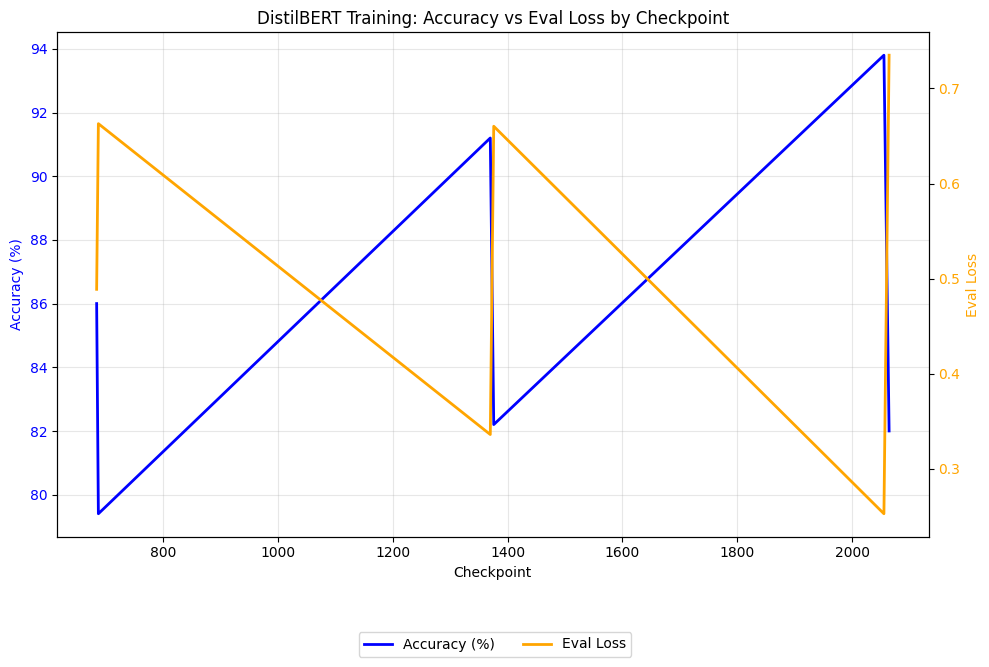

In [ ]:
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.plot(checkpoints, accuracy, color='blue', linewidth=2, label='Accuracy (%)')
ax1.set_xlabel('Checkpoint')
ax1.set_ylabel('Accuracy (%)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(checkpoints, loss, color='orange', linewidth=2, label='Eval Loss')
ax2.set_ylabel('Eval Loss', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

fig.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=2)
plt.title('DistilBERT Training: Accuracy vs Eval Loss by Checkpoint')
plt.tight_layout()
plt.show()


Model accuracy shows an overall upward trajectory from 86.0% (checkpoint 685) to a peak of 93.8% (checkpoint 2055), despite intermittent drops to 79.4-82.2%. This indicates progressive learning amid optimization instability.

Evaluation loss inversely correlates with accuracy peaks, dropping to 0.2528 at the highest accuracy checkpoint before spiking to 0.7350—consistent with high learning rate causing overshooting of local minima.

Those drops are not likely signs of overfitting, rather some inconsitent training, especially that the general direction of the model learning is going upwards. It may also be the effect of high learning rate.